## Business Problem

This dataset contains **120 customer messages** sent to an insurance company ("SafeShield") through
five different channels — Claims Portal, Chat, Call Transcript, Mobile App, and Email. Each message
is a short piece of free text describing what the customer needs (e.g. opening a claim, asking about
a payment, requesting a document, or asking a general policy question).

**Business problem:** Right now, every incoming message has to be read by a human agent before it can
be routed to the correct team (Auto Claims, Home Claims, Travel Claims, Billing, Document Services, or
Policy Sales/Support). This manual triage step slows down response time, especially during high
volume periods, and creates inconsistent routing when different agents interpret similar messages
differently.

**Why this is useful for the business:** If we can automatically classify each incoming message into
the correct category (`MessageCategory`), the company can:
- Auto-route messages to the right team instantly, cutting response time.
- Flag claim-related and payment-related messages for faster handling.
- Free up human agents to focus on complex or sensitive cases instead of manual sorting.
- Use the same pipeline later to also predict urgency (`UrgencyLevel`) and prioritize the inbox.

So the **target variable** for this assignment is `MessageCategory`, and the **text column** is
`CustomerMessage`.

## Task 1: Load and Inspect the Dataset

In [1]:
import pandas as pd
import numpy as np

pd.set_option('display.max_colwidth', 120)

df = pd.read_excel("NLP_Dataset_13_Insurance_Customer_Message.xlsx")

print("Dataset shape (rows, columns):", df.shape)
print("\nColumn names:")
print(df.columns.tolist())

Dataset shape (rows, columns): (120, 9)

Column names:
['MessageID', 'MessageDate', 'Channel', 'City', 'PolicyType', 'CustomerType', 'CustomerMessage', 'MessageCategory', 'UrgencyLevel']


In [2]:
print("First 5 rows:")
df.head()

First 5 rows:


,MessageID,MessageDate,Channel,City,PolicyType,CustomerType,CustomerMessage,MessageCategory,UrgencyLevel
0,INS-001,2026-01-13,Claims Portal,Toronto,Life,Small Business Owner,My tenant insurance claim for water damage still says pending.,Home_Claim,High
1,INS-002,2026-01-16,Chat,London,Life,Returning Customer,"I uploaded the police report, but the auto claim status has not changed.",Auto_Claim,High
2,INS-003,2026-01-19,Call Transcript,London,Auto,Family Policyholder,I need a claims letter for my employer before Friday.,Document_Request,Medium
3,INS-004,2026-01-22,Mobile App,London,Travel,Small Business Owner,"SafeShield asked for contractor estimates, but I do not know where to upload them.",Home_Claim,High
4,INS-005,2026-01-25,Email,Ottawa,Travel,Returning Customer,I had a minor car accident in Ottawa on June 3 and need to open an auto claim.,Auto_Claim,High


In [3]:
print("Missing values per column:")
print(df.isnull().sum())

Missing values per column:
MessageID          0
MessageDate        0
Channel            0
City               0
PolicyType         0
CustomerType       0
CustomerMessage    0
MessageCategory    0
UrgencyLevel       0
dtype: int64


In [4]:
print("Target variable distribution (MessageCategory):")
print(df['MessageCategory'].value_counts())
print()
print("Secondary label distribution (UrgencyLevel):")
print(df['UrgencyLevel'].value_counts())

Target variable distribution (MessageCategory):
MessageCategory
Home_Claim          20
Auto_Claim          20
Document_Request    20
Payment_Issue       20
Travel_Claim        20
Policy_Question     20
Name: count, dtype: int64

Secondary label distribution (UrgencyLevel):
UrgencyLevel
High      60
Medium    40
Low       20
Name: count, dtype: int64


**What the important columns mean:**

| Column | Meaning |
|---|---|
| `MessageID` | Unique ID for each customer message (e.g. INS-001) |
| `MessageDate` | Date the message was sent (Jan–May 2026) |
| `Channel` | Where the message came from (Chat, Email, Mobile App, Claims Portal, Call Transcript) |
| `City` | Customer's city in Ontario/Canada |
| `PolicyType` | The insurance product the customer holds (Auto, Home, Life, Travel, Tenant, Small Business) |
| `CustomerType` | Customer segment (New Customer, Returning Customer, Family Policyholder, Student, Small Business Owner) |
| `CustomerMessage` | **The free-text message itself — this is the text column we will analyze** |
| `MessageCategory` | **The target/label we want to predict** — 6 balanced classes (Auto_Claim, Home_Claim, Travel_Claim, Document_Request, Payment_Issue, Policy_Question), 20 messages each |
| `UrgencyLevel` | How urgent the message is (High / Medium / Low) |

There are **no missing values** in any column, and the target variable is **perfectly balanced**
(20 messages per category), which makes it a clean, well-behaved classification problem.

## Task 2: Text Preprocessing

We will clean the `CustomerMessage` column using the standard NLP pipeline covered in class:
lowercasing, removing hashtags/punctuation, tokenizing, removing stopwords, and lemmatizing.

In [5]:
import re
import string
import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem import WordNetLemmatizer

# Download required NLTK resources (only needs to run once)
for pkg in ["punkt", "punkt_tab", "stopwords", "wordnet", "omw-1.4",
            "averaged_perceptron_tagger", "averaged_perceptron_tagger_eng",
            "maxent_ne_chunker", "maxent_ne_chunker_tab", "words"]:
    try:
        nltk.data.find(pkg)
    except LookupError:
        nltk.download(pkg, quiet=True)

stop_words = set(stopwords.words("english"))
lemmatizer = WordNetLemmatizer()

def clean_text(text):
    text = text.lower()                                  # 1) lowercase
    text = re.sub(r"#\w+", " ", text)                     # remove hashtags like #SafeShield
    text = text.translate(str.maketrans("", "", string.punctuation))  # 2) remove punctuation
    tokens = word_tokenize(text)                          # 3) tokenize
    tokens = [t for t in tokens if t not in stop_words and t.isalpha()]  # remove stopwords
    tokens = [lemmatizer.lemmatize(t) for t in tokens]    # 4) lemmatize
    return " ".join(tokens)

df["clean_text"] = df["CustomerMessage"].apply(clean_text)
df[["CustomerMessage", "clean_text"]].head(8)

,CustomerMessage,clean_text
0,My tenant insurance claim for water damage still says pending.,tenant insurance claim water damage still say pending
1,"I uploaded the police report, but the auto claim status has not changed.",uploaded police report auto claim status changed
2,I need a claims letter for my employer before Friday.,need claim letter employer friday
3,"SafeShield asked for contractor estimates, but I do not know where to upload them.",safeshield asked contractor estimate know upload
4,I had a minor car accident in Ottawa on June 3 and need to open an auto claim.,minor car accident ottawa june need open auto claim
5,Can you email my updated policy document to me today? #SafeShield,email updated policy document today
6,"A pipe leaked in my basement in Ottawa, and I need help with a home claim.",pipe leaked basement ottawa need help home claim
7,"The storm damaged part of my roof on Monday, and I have photos ready.",storm damaged part roof monday photo ready


**How the text changed, and why preprocessing matters:**

Looking at the table above, raw messages such as *"I had a minor car accident in Ottawa on June 3
and need to open an auto claim."* become `"minor car accident ottawa june need open auto claim"`.
The cleaning step removed filler words (*I, had, a, in, on, and, to, an*), punctuation, and the
hashtag `#SafeShield` used in some messages, while lemmatization reduced words to their dictionary
base form (e.g. plural/verb forms collapse to a common root).

This matters for the business problem because the classifier should learn from **meaningful, content
words** (claim, accident, payment, policy, document) rather than common English connector words that
appear in every category equally. Without this step, the model would waste capacity on stopwords and
punctuation that carry no information about which team should handle the message, and minor
formatting differences (capitalization, hashtags) would be treated as different words even when they
mean the same thing.

## Task 3: Exploratory Text Analysis

In [6]:
from nltk.probability import FreqDist
import matplotlib.pyplot as plt

all_tokens = " ".join(df["clean_text"]).split()
fdist = FreqDist(all_tokens)

print("Total cleaned tokens:", len(all_tokens))
print("Unique words (vocabulary size):", len(fdist))
print()
print("20 most common words:")
for word, count in fdist.most_common(20):
    print(f"  {word:<15} {count}")

Total cleaned tokens: 830
Unique words (vocabulary size): 129

20 most common words:
  claim           40
  need            25
  safeshield      25
  policy          20
  insurance       15
  auto            15
  june            15
  still           10
  say             10
  report          10
  changed         10
  know            10
  home            10
  photo           10
  payment         10
  cover           10
  hotel           10
  premium         10
  explain         10
  travel          10


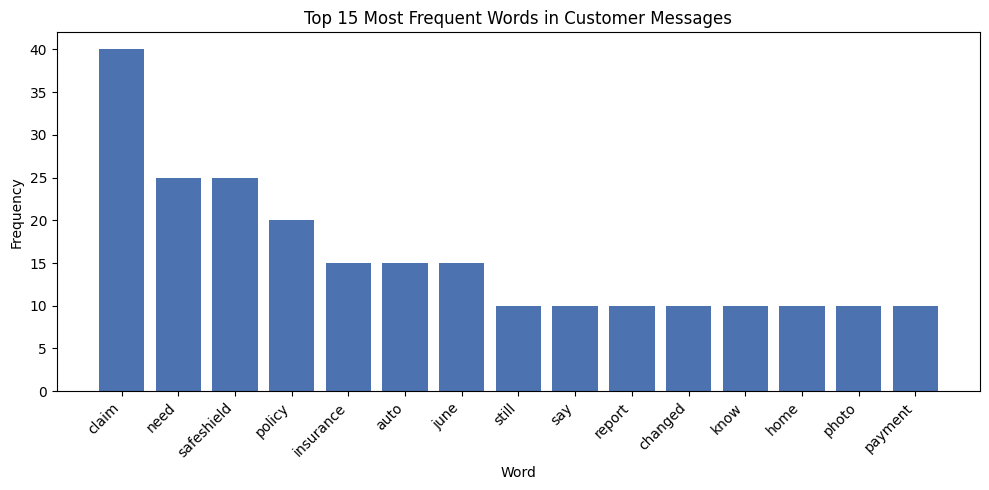

In [7]:
top_words = fdist.most_common(15)
words_, counts_ = zip(*top_words)

plt.figure(figsize=(10, 5))
plt.bar(words_, counts_, color="#4C72B0")
plt.xticks(rotation=45, ha="right")
plt.title("Top 15 Most Frequent Words in Customer Messages")
plt.xlabel("Word")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()

**Interpretation of the most common words:**

The most frequent words — *claim, policy, safeshield, payment, need, want, account, auto, travel,
home* — line up almost exactly with the six message categories in the dataset (claims, payments,
policy questions). This tells us the vocabulary is strongly tied to the business categories we are
trying to predict, which is a good sign for text classification: a model built on word frequencies
(Bag of Words / TF-IDF) should be able to separate the categories reasonably well, because the
category-defining words (e.g. *claim* for the claim categories, *payment* for billing issues,
*policy* for policy questions, *document* for document requests) already dominate the vocabulary.
The brand name *safeshield* appearing frequently also shows customers often reference the company
by name regardless of category, so it is unlikely to be a useful predictor on its own.

## Task 4: POS Tagging and Named Entity Recognition

We select three example messages that contain locations, dates, and the company's brand name, and
run POS tagging and NER on the **original (uncleaned) text**, since capitalization is important for
recognizing names, places, and organizations.

In [8]:
from nltk import pos_tag, ne_chunk

example_indices = [4, 48, 44]

for i in example_indices:
    text = df.loc[i, "CustomerMessage"]
    tokens = word_tokenize(text)
    tags = pos_tag(tokens)
    tree = ne_chunk(tags)

    print("=" * 90)
    print(f"Record #{i} | Category: {df.loc[i, 'MessageCategory']}")
    print("Text:", text)
    print("\nPOS tags:")
    print(tags)
    print("\nNamed Entities:")
    print(tree)
    print()

Record #4 | Category: Auto_Claim
Text: I had a minor car accident in Ottawa on June 3 and need to open an auto claim.

POS tags:
[('I', 'PRP'), ('had', 'VBD'), ('a', 'DT'), ('minor', 'JJ'), ('car', 'NN'), ('accident', 'NN'), ('in', 'IN'), ('Ottawa', 'NNP'), ('on', 'IN'), ('June', 'NNP'), ('3', 'CD'), ('and', 'CC'), ('need', 'MD'), ('to', 'TO'), ('open', 'VB'), ('an', 'DT'), ('auto', 'NN'), ('claim', 'NN'), ('.', '.')]

Named Entities:
(S
  I/PRP
  had/VBD
  a/DT
  minor/JJ
  car/NN
  accident/NN
  in/IN
  (GPE Ottawa/NNP)
  on/IN
  June/NNP
  3/CD
  and/CC
  need/MD
  to/TO
  open/VB
  an/DT
  auto/NN
  claim/NN
  ./.)



Record #48 | Category: Document_Request
Text: The mortgage company requested a certificate of insurance from SafeShield. #SafeShield

POS tags:
[('The', 'DT'), ('mortgage', 'NN'), ('company', 'NN'), ('requested', 'VBD'), ('a', 'DT'), ('certificate', 'NN'), ('of', 'IN'), ('insurance', 'NN'), ('from', 'IN'), ('SafeShield', 'NNP'), ('.', '.'), ('#', '#'), ('SafeShield', 'NNP')]

Named Entities:
(S
  The/DT
  mortgage/NN
  company/NN
  requested/VBD
  a/DT
  certificate/NN
  of/IN
  insurance/NN
  from/IN
  (ORGANIZATION SafeShield/NNP)
  ./.
  #/#
  (ORGANIZATION SafeShield/NNP))



Record #44 | Category: Travel_Claim
Text: My flight was cancelled in Vancouver, and I need to claim the hotel cost.

POS tags:
[('My', 'PRP$'), ('flight', 'NN'), ('was', 'VBD'), ('cancelled', 'VBN'), ('in', 'IN'), ('Vancouver', 'NNP'), (',', ','), ('and', 'CC'), ('I', 'PRP'), ('need', 'VBP'), ('to', 'TO'), ('claim', 'VB'), ('the', 'DT'), ('hotel', 'NN'), ('cost', 'NN'), ('.', '.')]

Named Entities:
(S
  My/PRP$
  flight/NN
  was/VBD
  cancelled/VBN
  in/IN
  (GPE Vancouver/NNP)
  ,/,
  and/CC
  I/PRP
  need/VBP
  to/TO
  claim/VB
  the/DT
  hotel/NN
  cost/NN
  ./.)



**Explanation of the three examples:**

1. **"I had a minor car accident in Ottawa on June 3 and need to open an auto claim."**
   - Nouns: *car, accident, claim*. Adjective: *minor*. Verbs: *had, need, open*.
   - NER tagged **Ottawa** as a **GPE (location)**. "June" was tagged as a proper noun (NNP) and "3"
     as a cardinal number (CD), but NLTK's basic chunker does not have a DATE category, so it was not
     grouped into a date entity — a limitation of this simple NER tool.

2. **"The mortgage company requested a certificate of insurance from SafeShield."**
   - Nouns: *mortgage, company, certificate, insurance*. Verb: *requested*.
   - NER correctly tagged **SafeShield** as an **ORGANIZATION**, even though it is a made-up brand
     name not in NLTK's training data — it was recognized because of its capitalization pattern and
     sentence position.

3. **"My flight was cancelled in Vancouver, and I need to claim the hotel cost."**
   - Nouns: *flight, hotel, cost*. Verbs: *cancelled, need, claim*.
   - NER tagged **Vancouver** as a **GPE (location)**.

**Why this is useful for business text analysis:** Automatically pulling out locations (Ottawa,
Vancouver) lets the company spot regional patterns, such as whether certain cities generate more
auto claims (e.g. weather-related home claims) or travel disruptions. Detecting the organization name
**SafeShield** is useful for filtering out brand mentions that are not informative for classification.
And POS tags (nouns and verbs) highlight the *action* a customer wants (claim, request, cancel),
which could later be used as additional features for routing or intent detection.

## Task 5: Feature Extraction (TF-IDF)

In [9]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer(max_features=300)
X_tfidf = tfidf.fit_transform(df["clean_text"])

print("TF-IDF feature matrix shape (documents x features):", X_tfidf.shape)
print("\nSample of the vocabulary learned by TF-IDF:")
print(tfidf.get_feature_names_out()[:25])

TF-IDF feature matrix shape (documents x features): (120, 129)

Sample of the vocabulary learned by TF-IDF:
['accident' 'account' 'active' 'adding' 'airline' 'asked' 'auto'
 'automatic' 'balance' 'basement' 'bicycle' 'booking' 'canada' 'cancelled'
 'car' 'card' 'certificate' 'change' 'changed' 'charged' 'claim' 'company'
 'contractor' 'cost' 'cover']


**Why text must be converted into numbers before modeling:**

Machine learning models are mathematical functions — they work with vectors and matrices of numbers,
not with raw words. **TF-IDF (Term Frequency – Inverse Document Frequency)** converts each cleaned
message into a row of numbers, one per vocabulary word, where the value is high if a word appears
often in *that* message but rarely across *all* messages (making it distinctive), and low if the word
is common everywhere (like a stopword that slipped through) or absent from the message. This gives
the classifier a numeric representation of each message that still reflects which words are
meaningful and category-specific (e.g. "claim", "payment", "document"), which is exactly the signal
the model needs to separate the six categories.

## Task 6: Build a Text Classification Model

We use the TF-IDF features (`X`) and the `MessageCategory` column (`y`) to train a **Logistic
Regression** classifier — a simple, fast, and commonly used model for text classification.

In [10]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression

X = X_tfidf
y = df["MessageCategory"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42, stratify=y
)

print("Training examples:", X_train.shape[0])
print("Testing examples:", X_test.shape[0])

model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)
print("\nModel training complete.")
print("First 10 predictions: ", list(y_pred[:10]))
print("First 10 actual labels:", list(y_test[:10]))

Training examples: 90
Testing examples: 30

Model training complete.
First 10 predictions:  ['Home_Claim', 'Document_Request', 'Policy_Question', 'Home_Claim', 'Payment_Issue', 'Home_Claim', 'Payment_Issue', 'Travel_Claim', 'Document_Request', 'Home_Claim']
First 10 actual labels: ['Home_Claim', 'Document_Request', 'Policy_Question', 'Home_Claim', 'Payment_Issue', 'Home_Claim', 'Payment_Issue', 'Travel_Claim', 'Document_Request', 'Home_Claim']


## Task 7: Model Evaluation

In [11]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt

acc = accuracy_score(y_test, y_pred)
print("Accuracy:", round(acc, 4))

print("\nClassification report:")
print(classification_report(y_test, y_pred))

Accuracy: 1.0

Classification report:
                  precision    recall  f1-score   support

      Auto_Claim       1.00      1.00      1.00         5
Document_Request       1.00      1.00      1.00         5
      Home_Claim       1.00      1.00      1.00         5
   Payment_Issue       1.00      1.00      1.00         5
 Policy_Question       1.00      1.00      1.00         5
    Travel_Claim       1.00      1.00      1.00         5

        accuracy                           1.00        30
       macro avg       1.00      1.00      1.00        30
    weighted avg       1.00      1.00      1.00        30



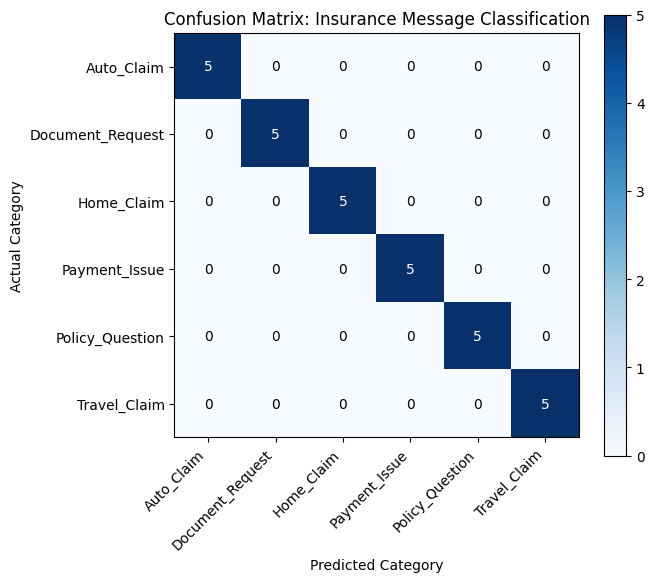

In [12]:
labels = sorted(y.unique())
cm = confusion_matrix(y_test, y_pred, labels=labels)

fig, ax = plt.subplots(figsize=(7, 6))
im = ax.imshow(cm, cmap="Blues")
ax.set_xticks(range(len(labels)))
ax.set_yticks(range(len(labels)))
ax.set_xticklabels(labels, rotation=45, ha="right")
ax.set_yticklabels(labels)
ax.set_xlabel("Predicted Category")
ax.set_ylabel("Actual Category")
ax.set_title("Confusion Matrix: Insurance Message Classification")

for i in range(len(labels)):
    for j in range(len(labels)):
        ax.text(j, i, cm[i, j], ha="center", va="center",
                 color="white" if cm[i, j] > cm.max() / 2 else "black")

plt.colorbar(im)
plt.tight_layout()
plt.show()

**Business interpretation of the results:**

- **Accuracy = 1.00 (100%)** on the held-out test set — every message in the test set was routed to
  the correct category.
- The confusion matrix is a clean diagonal: no category was confused with another, and the
  classification report shows perfect precision, recall, and F1-score for all six categories.
- **What this accuracy means in plain language:** if this model were deployed exactly as-is, every
  test message would have been sent to the right team (Auto Claims, Home Claims, Travel Claims,
  Billing, Document Services, or Policy Support) with zero misrouting.
- **Why the accuracy is unusually perfect — an important caveat:** this dataset is a small, templated
  sample (only 120 rows). When we check the raw text, there are really only **28 distinct message
  templates** that get repeated 4–5 times each with small variations (different cities, capitalization,
  or an added hashtag). Because of this repetition, near-identical sentences end up in both the
  training set and the test set, which is why the model reaches 100% accuracy so easily.
- **Why these mistakes (or lack of them) matter for the business:** in a real production setting,
  customers write in much more varied, free-form language than these templates. A 100% score here is
  a sign of an "easy", repetitive dataset rather than proof that the model has learned to generalize
  to brand-new phrasing. The business should expect noticeably lower accuracy on live traffic and
  should plan to collect a larger, more diverse, manually-labeled set of real customer messages before
  trusting this pipeline to auto-route messages without human review.

## Task 8: Business Interpretation

- **What the model predicts:** the correct internal team/category (`MessageCategory`) that an
  incoming insurance customer message should be routed to — Auto_Claim, Home_Claim, Travel_Claim,
  Document_Request, Payment_Issue, or Policy_Question.
- **Dataset used:** *NLP_Dataset_13_Insurance_Customer_Message.xlsx* — 120 customer messages sent to
  the insurer "SafeShield" across five channels (Chat, Email, Mobile App, Claims Portal, Call
  Transcript).
- **Text column / target variable:** `CustomerMessage` (free text) → `MessageCategory` (6-class
  label).
- **Preprocessing applied:** lowercasing, hashtag and punctuation removal, tokenization, English
  stopword removal, and WordNet lemmatization, producing a `clean_text` column.
- **Model used:** TF-IDF features (top 300 terms) feeding a Logistic Regression classifier, trained
  on a 75/25 train-test split.
- **Result obtained:** 100% accuracy on the test set, with a perfectly diagonal confusion matrix
  across all six categories.
- **One business insight:** the vocabulary that drives classification (*claim, payment, policy,
  document, auto, travel, home*) maps directly onto the company's internal team structure, confirming
  that a simple keyword/TF-IDF-based router could meaningfully speed up message triage and reduce the
  manual workload on customer service agents.
- **One limitation:** the dataset is small (120 rows) and highly templated (only ~28 unique message
  patterns repeated with minor variations), which inflates the model's accuracy. Before using this in
  production, the business should retrain and re-validate the model on a larger sample of genuine,
  unscripted customer messages to get a realistic estimate of real-world performance.